<a href="https://colab.research.google.com/github/InsightMart/DSPL_project/blob/main/XGB_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preperation

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import category_encoders as ce
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [ ]:
# Load Dataset using pandas library
import pandas as pd
df=pd.read_csv('/content/cleaned_traincsv.csv')

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [ ]:
# Encoding categorical variables
target_encoder = ce.TargetEncoder(handle_unknown='ignore')
df['encoded_outlet_city'] = target_encoder.fit_transform(df['outlet_city'], df['cluster_catgeory'])

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,encoded_outlet_city
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,3.251460
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,3.262522
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,3.267422
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,3.267422
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,3.251460


In [ ]:
# Create a dataframe for Featuers (X) and Targets (y)
X = df[['encoded_outlet_city', 'luxury_sales', 'fresh_sales', 'dry_sales']]
y = df['cluster_catgeory']

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=4. All the features will be returned.
  warnings.warn(


<Axes: >

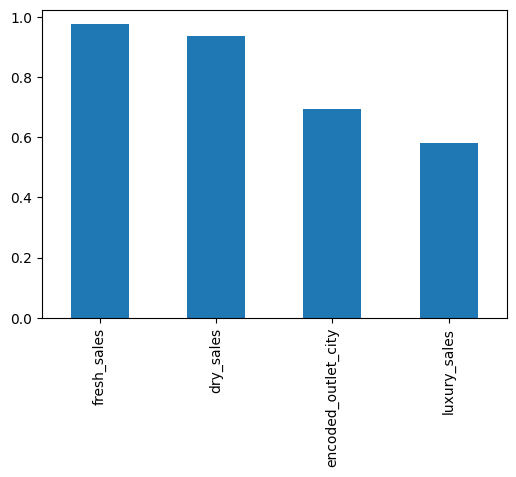

In [ ]:
# Feature importance

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(score_func=mutual_info_classif, k=10)
fs.fit(X, y)
mi_score = pd.Series(fs.scores_, index=X.columns)
mi_score.sort_values(ascending=False).plot.bar(figsize=(6, 4))

In [ ]:
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Whole Data shape', df.shape)
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

Whole Data shape (774150, 7)
X_train shape (541905, 4)
X_test shape (232245, 4)


## 7. XGBoost Model

In [ ]:
# Import the function from the package
from xgboost import XGBClassifier

y_train1 = y_train - 1  # Convert 1-6 to 0-5
y_test1 = y_test - 1

# Train xgb Model
xgb = XGBClassifier()
xgb.fit(X_train, y_train1)

# Perform predictions on the test data
y_pred7 = xgb.predict(X_test)

y_pred7 = y_pred7 + 1  # Convert 0-5 to 1-6

In [ ]:
# Get predicted probabilities for each class
y_prob7 = xgb.predict_proba(X_test)
y_prob7 = y_prob7 + 1

In [ ]:
# Create a dataframe for comparing the actual vs predicted results by XGBClassifier Model
compare_results_xgb_df = pd.DataFrame({'Actual cluster_catgeory' : y_test, 'Predicted cluster_catgeory': y_pred7})
compare_results_xgb_df

,Actual cluster_catgeory,Predicted cluster_catgeory
201122,2,2
207061,2,2
375630,1,1
552084,1,1
24499,4,4
...,...,...
253842,2,2
615954,6,6
338522,5,5
710046,6,6


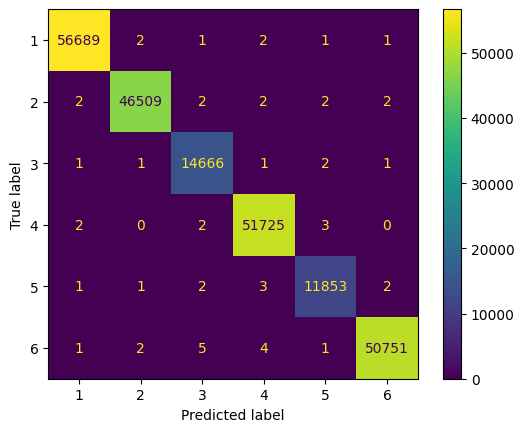

In [ ]:
# Import the required packages
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Construct the confusion matrix
xgb_cm = confusion_matrix(y_test, y_pred7, labels=np.unique(y_test))

# Plot the confusion matrix
disp_xgb_cm = ConfusionMatrixDisplay(xgb_cm, display_labels=np.unique(y_test))
disp_xgb_cm.plot()

In [ ]:
# Classification metrics report

# Import the function from the package
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred7))

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


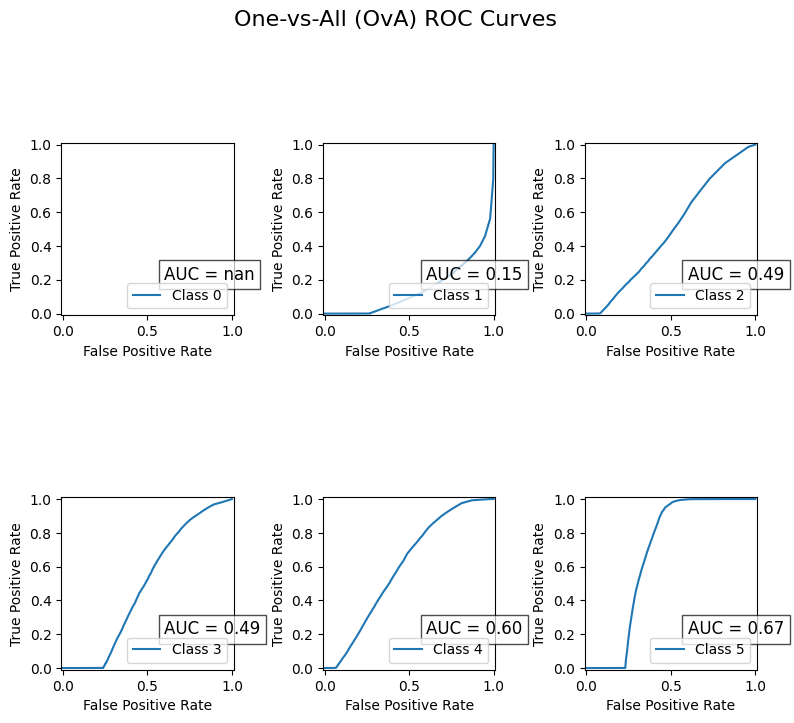

In [ ]:
# ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob7 = xgb.predict_proba(X_test)
y_prob7 = y_prob7 + 1

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(xgb.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob7[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob7[:, i])
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

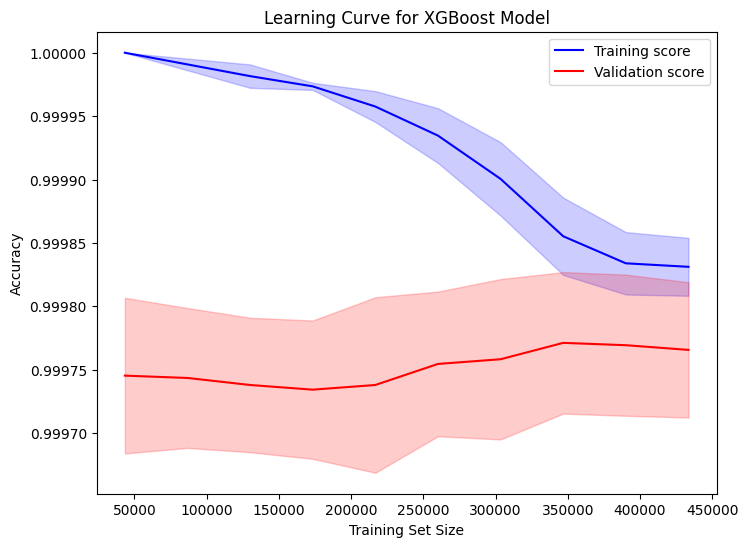

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


y_train1 = y_train - 1  # Convert 1-6 to 0-5
y_test1 = y_test - 1

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(xgb, X_train, y_train1,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='accuracy', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for XGBoost Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()

## 8. Tuned XGBoost Model

In [ ]:
# Import the function from the package
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

y_train1 = y_train - 1  # Convert 1-6 to 0-5
y_test1 = y_test - 1

# create new a nb model
xgb = XGBClassifier()

# Define hyperparameter grid
param_grid4 = {'n_estimators': [50, 100, 150],
               'learning_rate': [0.01, 0.1, 0.2],
               'max_depth': [3, 5, 7]}

#use gridsearch to test all values
xgb_gscv = GridSearchCV(xgb, param_grid4, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
#fit model to data
xgb_gscv.fit(X_train, y_train1)

# Get the best estimator (tuned model)
best_xgb = xgb_gscv.best_estimator_
best_xgb

Fitting 5 folds for each of 27 candidates, totalling 135 fits


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)


              precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



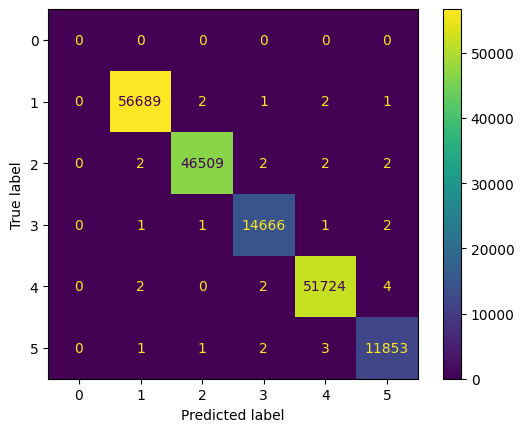

In [ ]:
# Perform testing on test dataset
y_pred8 = best_xgb.predict(X_test)
y_pred8 = y_pred8 + 1

# Construct a confusion matrix
cm_best_xgb = confusion_matrix(y_test, y_pred8, labels = best_xgb.classes_)
disp_best_xgb_cm = ConfusionMatrixDisplay(cm_best_xgb, display_labels=best_xgb.classes_)
disp_best_xgb_cm.plot()

# Display the classification report
print(classification_report(y_test, y_pred8))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


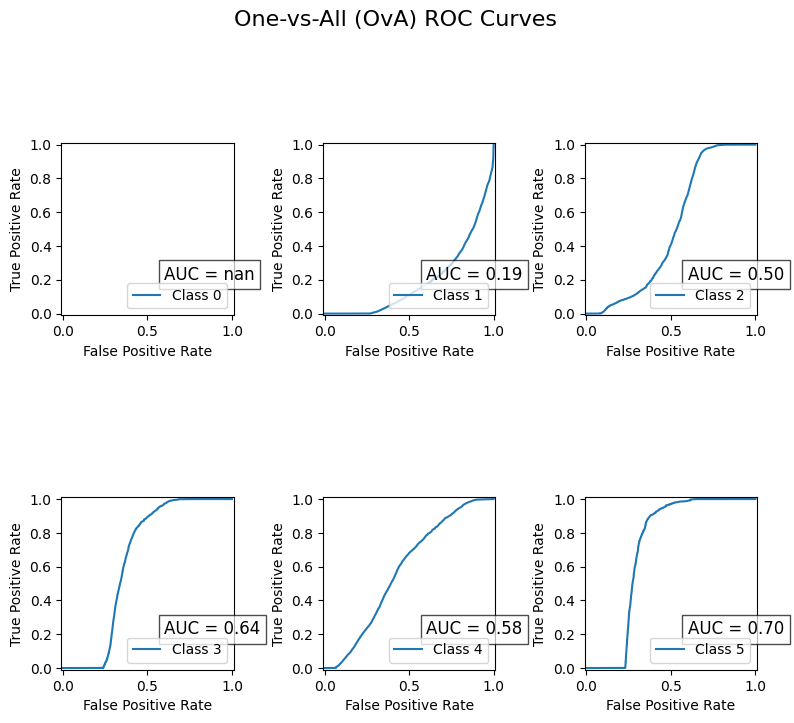

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob8 = best_xgb.predict_proba(X_test)
y_prob8 = y_prob8 + 1

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(best_xgb.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob8[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob8[:, i])  # Calculate AUC
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))  # Add AUC value to the plot

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to fit the suptitle
plt.show()

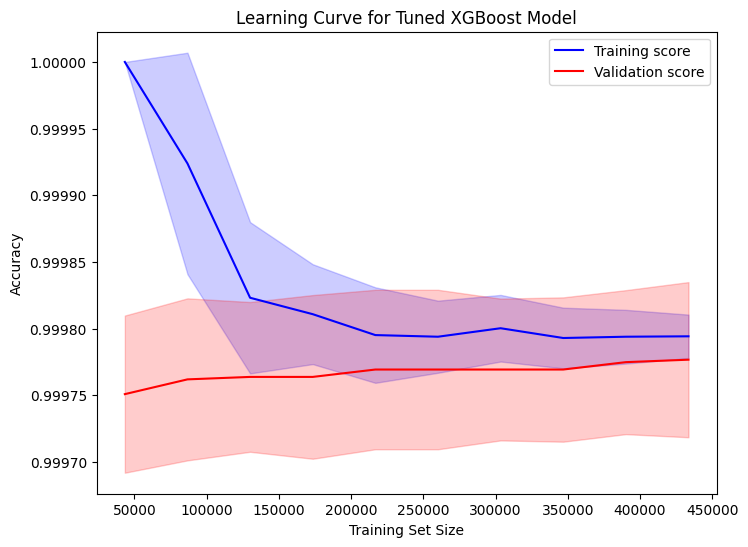

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(best_xgb, X_train, y_train1,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='accuracy', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for Tuned XGBoost Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()